# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

### Setup
Download `heart.csv` from the Kaggle link above and place it in the same folder as this notebook.

In [2]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("pgmpy").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from pgmpy.estimators import HillClimbSearch, PC, ExpertKnowledge
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

raw = pd.read_csv("heart.csv")
print(raw.shape)
raw.head()

ModuleNotFoundError: No module named 'pgmpy.parameter_estimator'

In [2]:
# Data quality check: Cholesterol = 0 and RestingBP = 0 are physiologically impossible (missing values)
print("Cholesterol == 0:", (raw.Cholesterol == 0).sum())
print("RestingBP == 0:  ", (raw.RestingBP == 0).sum())
raw.describe().T

Cholesterol == 0: 172
RestingBP == 0:   1


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [3]:
# Clean: treat zeros as missing and impute with the median of the valid values
df = raw.copy()
for col in ["Cholesterol", "RestingBP"]:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())
df["ExerciseAngina"] = (df["ExerciseAngina"] == "Y").astype(int)   # Y/N -> 1/0 so queries can use 1/0
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.538126,17.990127,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.204793,53.401297,85.0,214.0,237.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918.0,0.404139,0.490992,0.0,0.0,0.0,1.0,1.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.0,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.0,1.0,1.0,1.0


1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

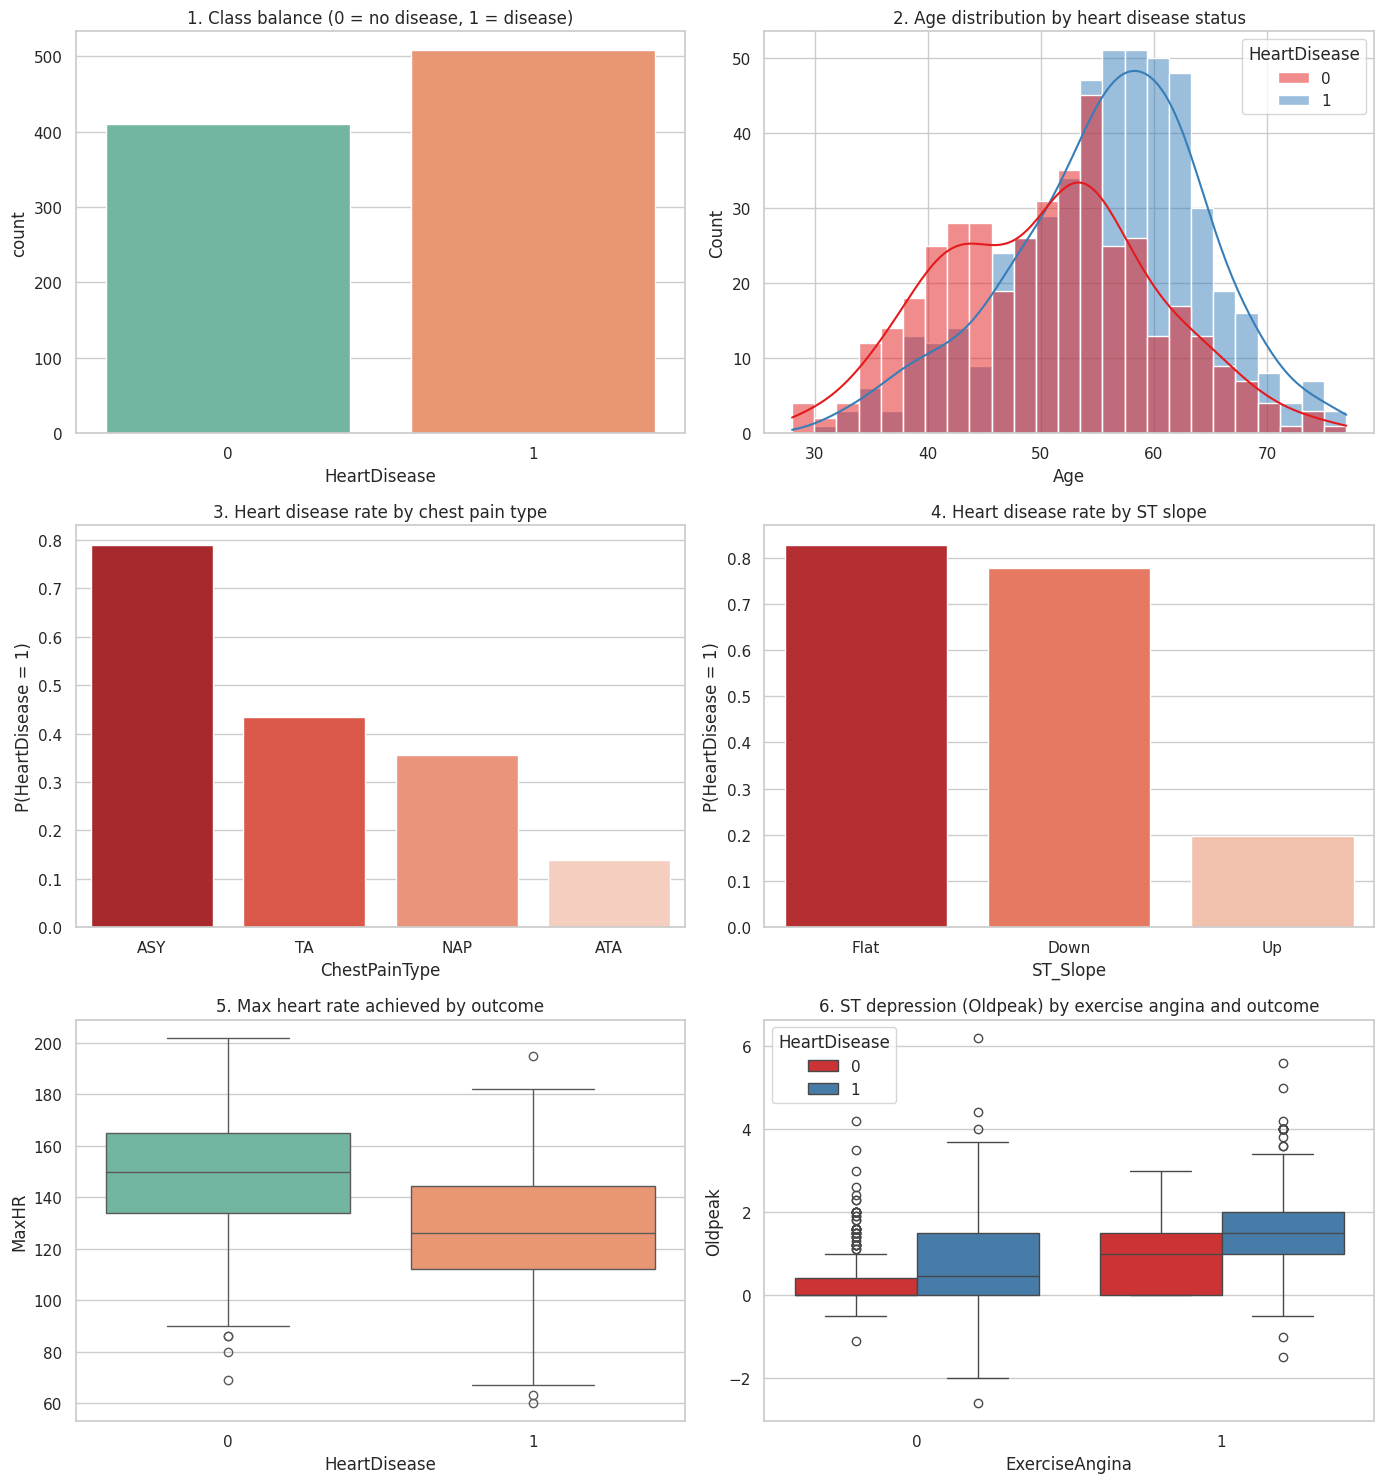

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Plot 1: Class balance
sns.countplot(x="HeartDisease", data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("1. Class balance (0 = no disease, 1 = disease)")

# Plot 2: Age distribution by outcome
sns.histplot(data=df, x="Age", hue="HeartDisease", kde=True, bins=25, ax=axes[0, 1], palette="Set1")
axes[0, 1].set_title("2. Age distribution by heart disease status")

# Plot 3: Disease rate by chest pain type
rate = df.groupby("ChestPainType")["HeartDisease"].mean().sort_values(ascending=False)
sns.barplot(x=rate.index, y=rate.values, ax=axes[1, 0], palette="Reds_r")
axes[1, 0].set_title("3. Heart disease rate by chest pain type")
axes[1, 0].set_ylabel("P(HeartDisease = 1)")

# Plot 4: Disease rate by ST slope
rate = df.groupby("ST_Slope")["HeartDisease"].mean().sort_values(ascending=False)
sns.barplot(x=rate.index, y=rate.values, ax=axes[1, 1], palette="Reds_r")
axes[1, 1].set_title("4. Heart disease rate by ST slope")
axes[1, 1].set_ylabel("P(HeartDisease = 1)")

# Plot 5: Max heart rate by outcome
sns.boxplot(x="HeartDisease", y="MaxHR", data=df, ax=axes[2, 0], palette="Set2")
axes[2, 0].set_title("5. Max heart rate achieved by outcome")

# Plot 6: Oldpeak (ST depression) by outcome and exercise angina
sns.boxplot(x="ExerciseAngina", y="Oldpeak", hue="HeartDisease", data=df, ax=axes[2, 1], palette="Set1")
axes[2, 1].set_title("6. ST depression (Oldpeak) by exercise angina and outcome")

plt.tight_layout()
plt.show()

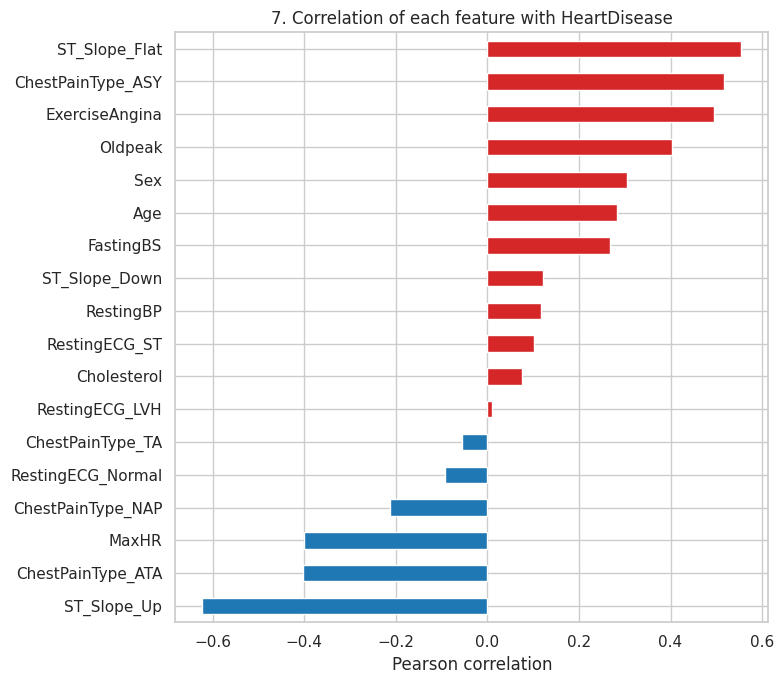

In [5]:
# Plot 7: Correlation of numeric/encoded features with the target
enc = df.copy()
enc["Sex"] = (enc["Sex"] == "M").astype(int)
enc = pd.get_dummies(enc, columns=["ChestPainType", "RestingECG", "ST_Slope"], dtype=int)
corr = enc.corr()["HeartDisease"].drop("HeartDisease").sort_values()
plt.figure(figsize=(8, 7))
corr.plot(kind="barh", color=["tab:blue" if v < 0 else "tab:red" for v in corr])
plt.title("7. Correlation of each feature with HeartDisease")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

In [6]:
# Supporting numbers: disease rate within key groups
for col in ["Sex", "ExerciseAngina", "FastingBS", "ChestPainType", "ST_Slope"]:
    print(df.groupby(col)["HeartDisease"].agg(["mean", "count"]).round(3), "\n")

      mean  count
Sex              
F    0.259    193
M    0.632    725 

                 mean  count
ExerciseAngina              
0               0.351    547
1               0.852    371 

            mean  count
FastingBS              
0          0.480    704
1          0.794    214 

                mean  count
ChestPainType              
ASY            0.790    496
ATA            0.139    173
NAP            0.355    203
TA             0.435     46 

           mean  count
ST_Slope              
Down      0.778     63
Flat      0.828    460
Up        0.197    395 



#### Discretization for the Bayesian Network
Discrete BNs need categorical variables, so continuous features are binned using clinically meaningful cut-points (e.g., ACC/AHA cholesterol thresholds of 200 and 240 mg/dL, blood pressure stages of 120 and 140 mmHg).

In [7]:
data = pd.DataFrame({
    "Age_bin":         pd.cut(df.Age, [0, 44, 59, 200], labels=["<45", "45-59", "60+"]).astype(str),
    "Sex":             df.Sex,
    "ChestPainType":   df.ChestPainType,
    "RestingBP_bin":   pd.cut(df.RestingBP, [0, 119, 139, 999], labels=["Normal", "Elevated", "High"]).astype(str),
    "Cholesterol_bin": pd.cut(df.Cholesterol, [0, 199, 239, 9999], labels=["Normal", "Borderline", "High"]).astype(str),
    "FastingBS":       df.FastingBS,
    "RestingECG":      df.RestingECG,
    "MaxHR_bin":       pd.cut(df.MaxHR, [0, 119, 150, 999], labels=["Low", "Medium", "High"]).astype(str),
    "ExerciseAngina":  df.ExerciseAngina,
    "Oldpeak_bin":     pd.cut(df.Oldpeak, [-99, 0.5, 2.0, 99], labels=["Low", "Medium", "High"]).astype(str),
    "ST_Slope":        df.ST_Slope,
    "HeartDisease":    df.HeartDisease,
}).astype("category")   # all categorical so pgmpy treats every variable as discrete

for c in data.columns:
    print(f"{c:16s}", dict(data[c].value_counts()))

Age_bin          {'45-59': np.int64(487), '60+': np.int64(253), '<45': np.int64(178)}
Sex              {'M': np.int64(725), 'F': np.int64(193)}
ChestPainType    {'ASY': np.int64(496), 'NAP': np.int64(203), 'ATA': np.int64(173), 'TA': np.int64(46)}
RestingBP_bin    {'Elevated': np.int64(431), 'High': np.int64(327), 'Normal': np.int64(160)}
Cholesterol_bin  {'Borderline': np.int64(409), 'High': np.int64(363), 'Normal': np.int64(146)}
FastingBS        {0: np.int64(704), 1: np.int64(214)}
RestingECG       {'Normal': np.int64(552), 'LVH': np.int64(188), 'ST': np.int64(178)}
MaxHR_bin        {'Medium': np.int64(415), 'High': np.int64(278), 'Low': np.int64(225)}
ExerciseAngina   {0: np.int64(547), 1: np.int64(371)}
Oldpeak_bin      {'Low': np.int64(458), 'Medium': np.int64(360), 'High': np.int64(100)}
ST_Slope         {'Flat': np.int64(460), 'Up': np.int64(395), 'Down': np.int64(63)}
HeartDisease     {1: np.int64(508), 0: np.int64(410)}


**Answer – Key risk factors observed**

The strongest signal comes from the exercise stress-test findings: patients with a **Flat (82.8%) or Down-sloping (77.8%) ST segment** have heart disease far more often than those with an Up-sloping segment (19.7%), and **exercise-induced angina** raises the disease rate from 35.1% to 85.2%. **Asymptomatic (ASY) chest pain** is, counter-intuitively, the most dangerous chest pain category (79.0% disease vs. only 13.9% for atypical angina, ATA), which reflects silent ischemia in this referral population. Patients with heart disease also tend to be **older, male** (63.2% of men vs. 25.9% of women), have a **lower maximum heart rate** and a **higher Oldpeak** (ST depression), and **elevated fasting blood sugar** raises the rate from 48.0% to 79.4%. Cholesterol is a weak and misleading predictor here because 172 patients have an impossible value of 0 (treated as missing and median-imputed), so it should not be read as "cholesterol doesn't matter" clinically.

2. Bayesian Network Structure Learning
    * Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
    * Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

In [8]:
def draw_bn(edges, nodes, title, ax):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    pos = nx.circular_layout(G)
    colors = ["salmon" if n == "HeartDisease" else "lightblue" for n in G.nodes]
    nx.draw_networkx(G, pos, ax=ax, node_color=colors, node_size=2600, font_size=8,
                     arrowsize=18, edge_color="gray", connectionstyle="arc3,rad=0.08")
    ax.set_title(f"{title}\n({len(edges)} edges)")
    ax.axis("off")

nodes = list(data.columns)

# Algorithm 1: Hill-Climb search (score-based) with BIC score
hc_dag = HillClimbSearch(data).estimate(scoring_method="bic-d", show_progress=False)

# Algorithm 2: PC algorithm (constraint-based) with chi-square independence tests
pc_dag = PC(data).estimate(variant="stable", n_jobs=1, ci_test="chi_square", return_type="dag", significance_level=0.01, show_progress=False)

# Algorithm 3: Hill-Climb + BIC with clinical expert knowledge:
#   nothing can cause a patient's Age or Sex, so all edges INTO those nodes are forbidden
forbidden = [(c, "Age_bin") for c in nodes if c != "Age_bin"] + [(c, "Sex") for c in nodes if c != "Sex"]
hc_ek_dag = HillClimbSearch(data).estimate(scoring_method="bic-d",
                                           expert_knowledge=ExpertKnowledge(forbidden_edges=forbidden),
                                           show_progress=False)

for name, g in [("Hill-Climb (BIC)", hc_dag), ("PC (chi-square)", pc_dag), ("Hill-Climb + expert constraints", hc_ek_dag)]:
    print(f"\n{name}:")
    for e in sorted(g.edges()):
        print("   ", e[0], "->", e[1])


Hill-Climb (BIC):
    Age_bin -> RestingBP_bin
    Age_bin -> RestingECG
    ChestPainType -> HeartDisease
    ExerciseAngina -> MaxHR_bin
    FastingBS -> Cholesterol_bin
    HeartDisease -> ExerciseAngina
    HeartDisease -> FastingBS
    HeartDisease -> MaxHR_bin
    HeartDisease -> Oldpeak_bin
    HeartDisease -> ST_Slope
    HeartDisease -> Sex
    MaxHR_bin -> Age_bin
    Oldpeak_bin -> ExerciseAngina
    ST_Slope -> Oldpeak_bin

PC (chi-square):
    ChestPainType -> HeartDisease
    ExerciseAngina -> ChestPainType
    ExerciseAngina -> MaxHR_bin
    FastingBS -> Cholesterol_bin
    HeartDisease -> ST_Slope
    Oldpeak_bin -> ExerciseAngina
    Oldpeak_bin -> HeartDisease
    Oldpeak_bin -> ST_Slope
    RestingBP_bin -> Age_bin
    RestingECG -> Cholesterol_bin

Hill-Climb + expert constraints:
    Age_bin -> HeartDisease
    Age_bin -> RestingBP_bin
    Age_bin -> RestingECG
    ExerciseAngina -> ChestPainType
    ExerciseAngina -> MaxHR_bin
    FastingBS -> Cholesterol_bin
   

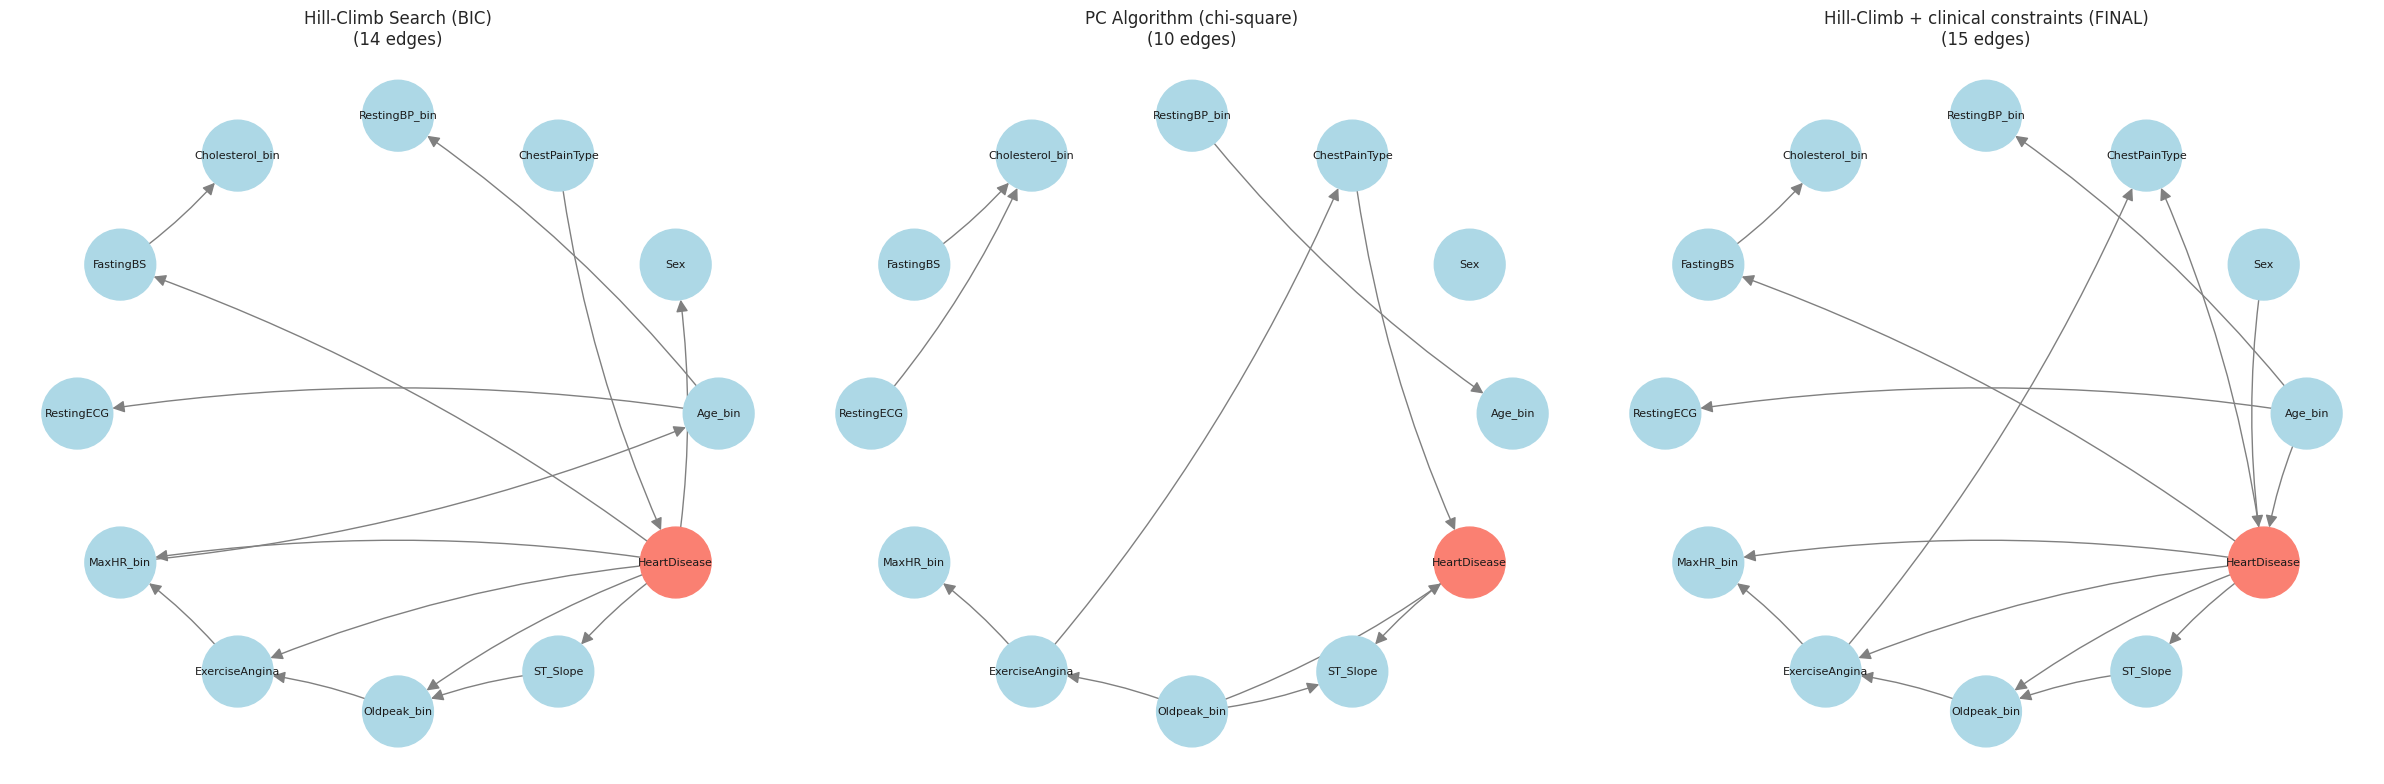

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
draw_bn(hc_dag.edges(), nodes, "Hill-Climb Search (BIC)", axes[0])
draw_bn(pc_dag.edges(), nodes, "PC Algorithm (chi-square)", axes[1])
draw_bn(hc_ek_dag.edges(), nodes, "Hill-Climb + clinical constraints (FINAL)", axes[2])
plt.tight_layout()
plt.show()

In [10]:
# Compare how well each structure fits the data (higher BIC score = better)
from pgmpy.estimators import BIC
bic = BIC(data)
for name, g in [("Hill-Climb (BIC)", hc_dag), ("PC (chi-square)", pc_dag), ("Hill-Climb + constraints", hc_ek_dag)]:
    m = DiscreteBayesianNetwork(g.edges()); m.add_nodes_from(nodes)
    print(f"{name:28s} BIC = {bic.score(m):10.1f}   parents of HeartDisease: {list(m.get_parents('HeartDisease'))}   "
          f"isolated nodes: {[n for n in m.nodes if m.degree(n) == 0]}")

Hill-Climb (BIC)             BIC =    -8859.6   parents of HeartDisease: ['ChestPainType']   isolated nodes: []
PC (chi-square)              BIC =    -9029.2   parents of HeartDisease: ['Oldpeak_bin', 'ChestPainType']   isolated nodes: ['Sex']
Hill-Climb + constraints     BIC =    -8863.8   parents of HeartDisease: ['Age_bin', 'Sex']   isolated nodes: []


**Answer – Choice of structure**

I compared **Hill-Climb search with the BIC score** (score-based), the **PC algorithm with chi-square tests** (constraint-based), and Hill-Climb + BIC again with **clinical expert constraints** that forbid any edge pointing *into* Age or Sex. The plain Hill-Climb graph fits well but contains causally impossible arrows (`HeartDisease → Sex` and `MaxHR_bin → Age_bin`), and the PC graph is sparser, has a clearly worse BIC score, leaves **Sex completely disconnected**, cuts Age off from heart disease, and even includes `RestingBP_bin → Age_bin`. I chose the **constrained Hill-Climb network** because it has almost the same BIC as the unconstrained one, but reads like a clinician's mental model: demographic risk factors (**Age, Sex**) cause **HeartDisease**, which in turn produces the observable findings (chest pain type, exercise angina, low MaxHR, ST slope, Oldpeak, fasting blood sugar).

*Note: PC's edge orientations can shift slightly between runs (pgmpy orients undirected edges using Python set ordering), but its qualitative weaknesses above appear in every run.*

3. Parameter Learning & Clinical Inference
    * Fit the conditional probability tables (CPTs) on the full data, then perform and interpret these five queries (show the numerical result + 2–3 sentence interpretation for each):

        **a) P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat'**
      
        **b) Same patient but with ExerciseAngina=1**
      
        **c) P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low')**
      
        **d) P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0)**
      
        **e) Full diagnostic: P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High')**

In [11]:
# Final model: fit CPTs on the full dataset.
# BayesianEstimator with a small BDeu prior avoids zero probabilities for rare combinations.
model = DiscreteBayesianNetwork(hc_ek_dag.edges())
model.add_nodes_from(nodes)
model.fit(data, estimator=DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=5))
print("Model valid:", model.check_model())
# CPT of HeartDisease given its parents (Age_bin, Sex), shown as P(HeartDisease=1)
ve = VariableElimination(model)
tbl = pd.DataFrame({sex: {age: ve.query(["HeartDisease"], evidence={"Age_bin": age, "Sex": sex}, show_progress=False).get_value(HeartDisease=1)
                          for age in ["<45", "45-59", "60+"]} for sex in ["F", "M"]})
print("\nP(HeartDisease=1 | Age_bin, Sex):")
print(tbl.round(3))

Model valid: True

P(HeartDisease=1 | Age_bin, Sex):
           F      M
<45    0.126  0.390
45-59  0.240  0.624
60+    0.421  0.807


In [12]:
infer = VariableElimination(model)
baseline = data.HeartDisease.astype(int).mean()
print(f"Baseline prevalence P(HeartDisease=1) = {baseline:.3f}\n")

queries = {
    "a) Age 60+, ST_Slope Flat":                                  {"Age_bin": "60+", "ST_Slope": "Flat"},
    "b) Age 60+, ST_Slope Flat, ExerciseAngina=1":                {"Age_bin": "60+", "ST_Slope": "Flat", "ExerciseAngina": 1},
    "c) Cholesterol High, MaxHR Low":                             {"Cholesterol_bin": "High", "MaxHR_bin": "Low"},
    "d) ChestPainType ATA, ExerciseAngina=0":                     {"ChestPainType": "ATA", "ExerciseAngina": 0},
    "e) Age 60+, Flat slope, ExerciseAngina=1, Oldpeak High":     {"Age_bin": "60+", "ST_Slope": "Flat", "ExerciseAngina": 1, "Oldpeak_bin": "High"},
}

results = {}
for label, ev in queries.items():
    q = infer.query(["HeartDisease"], evidence=ev, show_progress=False)
    p = q.get_value(HeartDisease=1)
    results[label] = p
    print(f"{label:60s} P(HeartDisease=1) = {p:.3f}")

Baseline prevalence P(HeartDisease=1) = 0.553

a) Age 60+, ST_Slope Flat                                    P(HeartDisease=1) = 0.911
b) Age 60+, ST_Slope Flat, ExerciseAngina=1                  P(HeartDisease=1) = 0.966
c) Cholesterol High, MaxHR Low                               P(HeartDisease=1) = 0.774
d) ChestPainType ATA, ExerciseAngina=0                       P(HeartDisease=1) = 0.098
e) Age 60+, Flat slope, ExerciseAngina=1, Oldpeak High       P(HeartDisease=1) = 0.988


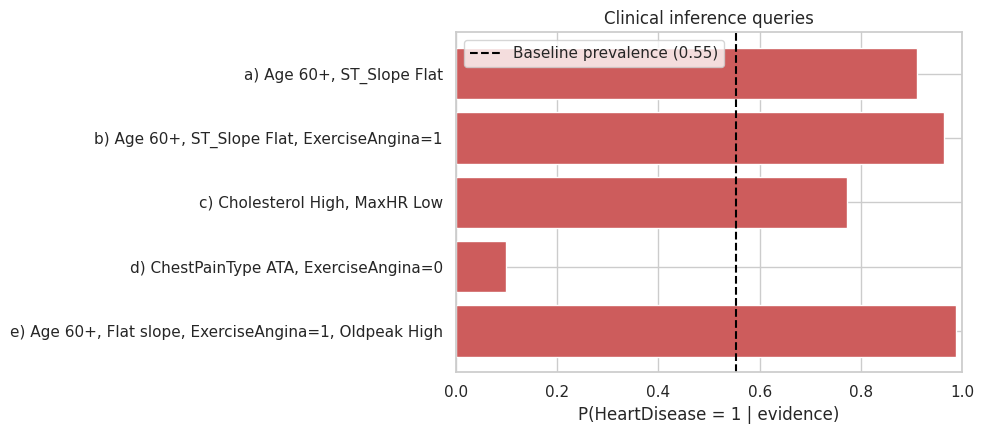

In [13]:
# Visual summary of the five queries vs. baseline
plt.figure(figsize=(10, 4.5))
plt.barh(list(results.keys())[::-1], list(results.values())[::-1], color="indianred")
plt.axvline(baseline, ls="--", color="black", label=f"Baseline prevalence ({baseline:.2f})")
plt.xlim(0, 1); plt.xlabel("P(HeartDisease = 1 | evidence)"); plt.legend()
plt.title("Clinical inference queries")
plt.tight_layout(); plt.show()

In [14]:
# Explainability: empirical check of each query against raw counts (sanity check)
for label, ev in queries.items():
    mask = np.ones(len(data), dtype=bool)
    for k, v in ev.items():
        mask &= (data[k] == v).values
    print(f"{label:60s} n = {mask.sum():3d}   empirical rate = {data.HeartDisease[mask].astype(int).mean():.3f}")

a) Age 60+, ST_Slope Flat                                    n = 150   empirical rate = 0.867


b) Age 60+, ST_Slope Flat, ExerciseAngina=1                  n =  91   empirical rate = 0.934
c) Cholesterol High, MaxHR Low                               n =  74   empirical rate = 0.784
d) ChestPainType ATA, ExerciseAngina=0                       n = 156   empirical rate = 0.096
e) Age 60+, Flat slope, ExerciseAngina=1, Oldpeak High       n =  13   empirical rate = 1.000


**Answer – Inference results** (baseline prevalence P(HeartDisease=1) = 0.553)

| Query | Evidence | P(HeartDisease=1) | Raw-data rate (n) |
|---|---|---|---|
| a | Age 60+, ST_Slope Flat | **0.911** | 0.867 (150) |
| b | + ExerciseAngina = 1 | **0.966** | 0.934 (91) |
| c | Cholesterol High, MaxHR Low | **0.774** | 0.784 (74) |
| d | ChestPainType ATA, ExerciseAngina = 0 | **0.098** | 0.096 (156) |
| e | Age 60+, Flat, ExerciseAngina = 1, Oldpeak High | **0.988** | 1.000 (13) |

**a)** An older patient with a flat ST slope has a 91.1% probability of heart disease, versus 55.3% for the average patient. A flat slope alone already gives 82.7%, and being 60+ (72.5% on its own) pushes it higher, so these two findings together put the patient firmly in the high-risk group and justify further work-up such as angiography.

**b)** Adding exercise-induced angina raises the probability to 96.6%. Because angina during exercise is a direct symptom of ischemia, it adds independent evidence on top of the ECG finding; the remaining uncertainty drops from about 9% to about 3%.

**c)** High cholesterol plus a low max heart rate gives 77.4%, which is almost exactly what low MaxHR gives alone (78.4%). In this network cholesterol is only linked to heart disease indirectly (through fasting blood sugar), and in this dataset high cholesterol barely moves risk (53.7% vs. 55.3% baseline), partly because the 172 missing-cholesterol patients, who are mostly diseased, were imputed into the Borderline group. The risk here is driven by the poor heart-rate response to exercise (chronotropic incompetence), not by cholesterol.

**d)** A patient with atypical angina (ATA) and no exercise angina has only a 9.8% probability, well below baseline. Both findings point away from ischemic heart disease, so the model would classify this patient as low risk, a reassuring result that could support avoiding unnecessary invasive testing.

**e)** With every major warning sign present the model is 98.8% confident of heart disease. Large ST depression (Oldpeak > 2) on top of a flat slope and exercise angina is a classic positive stress test; note that only 13 patients in the data match this exact profile (all of them diseased), and the Bayesian network gives a stable estimate by combining the CPTs rather than relying only on that tiny group.

4. Turn your Bayesian Network into a probabilistic classifier
    * For each patient, compute P(HeartDisease=1 | all observed features)
    * Predict 1 if probability > 0.5
    * Report accuracy and AUC (optional but encouraged: use a 70/30 train/test split so numbers are realistic)

In [15]:
# 70/30 stratified split; learn CPTs on the training set only (structure kept from Part 2)
train, test = train_test_split(data, test_size=0.30, stratify=data.HeartDisease, random_state=RANDOM_STATE)

bn_clf = DiscreteBayesianNetwork(hc_ek_dag.edges())
bn_clf.add_nodes_from(nodes)
states = {c: list(data[c].cat.categories) for c in nodes}   # keep every state even if rare in the training split
bn_clf.fit(train, estimator=DiscreteBayesianEstimator(state_names=states, prior_type="BDeu", equivalent_sample_size=5))
clf_infer = VariableElimination(bn_clf)

def predict_proba(df_in, inference):
    probs = []
    for _, row in df_in.drop(columns="HeartDisease").iterrows():
        q = inference.query(["HeartDisease"], evidence=row.to_dict(), show_progress=False)
        probs.append(q.get_value(HeartDisease=1))
    return np.array(probs)

y_test  = test.HeartDisease.astype(int).values
p_test  = predict_proba(test, clf_infer)
yhat    = (p_test > 0.5).astype(int)

y_train = train.HeartDisease.astype(int).values
p_train = predict_proba(train, clf_infer)

print(f"Train accuracy: {accuracy_score(y_train, p_train > 0.5):.3f}   Train AUC: {roc_auc_score(y_train, p_train):.3f}")
print(f"Test  accuracy: {accuracy_score(y_test, yhat):.3f}   Test  AUC: {roc_auc_score(y_test, p_test):.3f}\n")
print(classification_report(y_test, yhat, target_names=["No disease", "Disease"]))

Train accuracy: 0.863   Train AUC: 0.924
Test  accuracy: 0.870   Test  AUC: 0.939

              precision    recall  f1-score   support

  No disease       0.86      0.85      0.85       123
     Disease       0.88      0.89      0.88       153

    accuracy                           0.87       276
   macro avg       0.87      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276



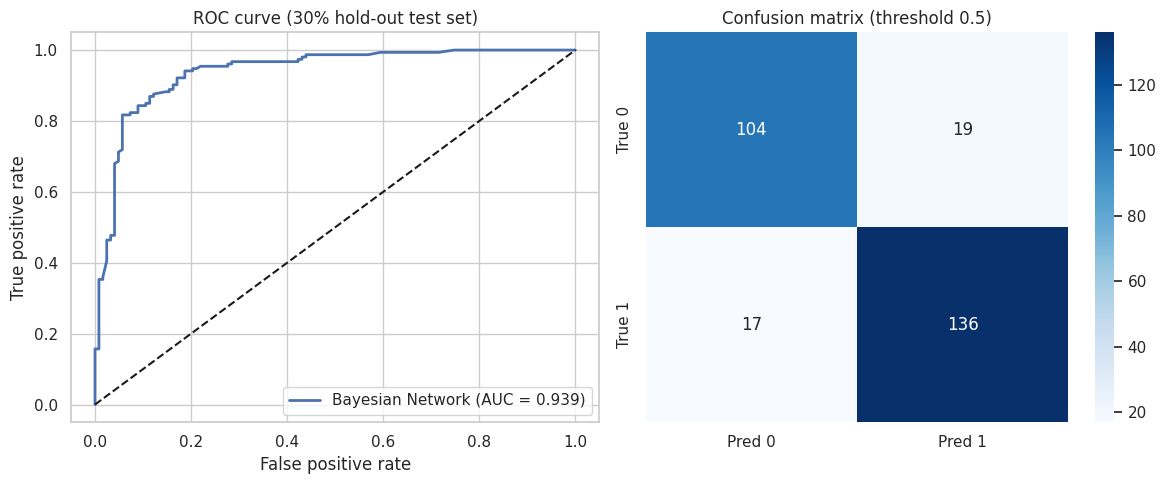

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, lw=2, label=f"Bayesian Network (AUC = {roc_auc_score(y_test, p_test):.3f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (30% hold-out test set)"); axes[0].legend()

sns.heatmap(confusion_matrix(y_test, yhat), annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
axes[1].set_title("Confusion matrix (threshold 0.5)")
plt.tight_layout(); plt.show()

In [17]:
# Reference point for Part 5: a black-box gradient-boosting model on the same split (raw, unbinned features)
from sklearn.ensemble import GradientBoostingClassifier
X = pd.get_dummies(df.drop(columns="HeartDisease"), dtype=int)
X_tr, X_te = X.loc[train.index], X.loc[test.index]
gb = GradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_tr, y_train)
p_gb = gb.predict_proba(X_te)[:, 1]
print(f"Gradient Boosting  test accuracy: {accuracy_score(y_test, p_gb > 0.5):.3f}   AUC: {roc_auc_score(y_test, p_gb):.3f}")
print(f"Bayesian Network   test accuracy: {accuracy_score(y_test, yhat):.3f}   AUC: {roc_auc_score(y_test, p_test):.3f}")

Gradient Boosting  test accuracy: 0.888   AUC: 0.933
Bayesian Network   test accuracy: 0.870   AUC: 0.939


In [18]:
# Explainability demo: why did the BN flag a specific test patient?
idx = np.argmin(np.abs(p_test - 0.65))   # a borderline patient, where explanations matter most
patient = test.drop(columns="HeartDisease").iloc[idx].to_dict()
print("Patient evidence:", patient)
print(f"P(HeartDisease=1 | all evidence) = {p_test[idx]:.3f}\n")
print("Contribution of each finding (probability when that one finding is removed):")
for k in patient:
    ev = {kk: vv for kk, vv in patient.items() if kk != k}
    p = clf_infer.query(["HeartDisease"], evidence=ev, show_progress=False).get_value(HeartDisease=1)
    print(f"   without {k:16s} -> {p:.3f}   (change {p - p_test[idx]:+.3f})")

Patient evidence: {'Age_bin': '45-59', 'Sex': 'M', 'ChestPainType': 'NAP', 'RestingBP_bin': 'High', 'Cholesterol_bin': 'High', 'FastingBS': 0, 'RestingECG': 'Normal', 'MaxHR_bin': 'Medium', 'ExerciseAngina': 0, 'Oldpeak_bin': 'Low', 'ST_Slope': 'Flat'}
P(HeartDisease=1 | all evidence) = 0.648

Contribution of each finding (probability when that one finding is removed):
   without Age_bin          -> 0.688   (change +0.040)
   without Sex              -> 0.576   (change -0.072)
   without ChestPainType    -> 0.771   (change +0.123)
   without RestingBP_bin    -> 0.648   (change +0.000)
   without Cholesterol_bin  -> 0.648   (change +0.000)
   without FastingBS        -> 0.693   (change +0.045)
   without RestingECG       -> 0.648   (change +0.000)
   without MaxHR_bin        -> 0.645   (change -0.003)
   without ExerciseAngina   -> 0.712   (change +0.064)
   without Oldpeak_bin      -> 0.517   (change -0.131)
   without ST_Slope         -> 0.153   (change -0.496)


**Answer – Classifier performance** (CPTs learned on a stratified 70% training split; evaluated on the 30% hold-out set of 276 patients)

| Set | Accuracy | AUC |
|---|---|---|
| Train (642 patients) | 0.863 | 0.924 |
| **Test (276 patients)** | **0.870** | **0.939** |

The Bayesian network classifier reaches **87.0% accuracy and an AUC of 0.939** on unseen patients, with balanced precision/recall (0.88/0.89 for the disease class). Train and test scores are nearly identical, so the model is not overfitting, which is expected from a sparse network with only 15 edges. For reference, a black-box gradient-boosting model on the same split and the raw (unbinned) features got 88.8% accuracy and AUC 0.933: about 2 points more accurate but no better at ranking patients by risk. The last cell also shows how each individual prediction can be explained by removing one finding at a time (for the borderline patient shown, the Flat ST slope alone moves the risk from about 15% to 65%).

5. Answer both questions clearly:
    * Why might a hospital or cardiologist prefer your Bayesian Network over a neural network or XGBoost that has 3–5% higher accuracy?
    * Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice (a 30-second Google is allowed – just cite your source).

**Answer**

**Why a hospital might prefer the Bayesian network over a model with 3–5% higher accuracy:**
* **Explainability and trust:** every prediction can be traced through a small graph and readable probability tables ("risk is 97% *because* the ST slope is flat and the patient has exercise angina"), which clinicians can check against their own knowledge. A neural network or XGBoost model needs post-hoc approximations like SHAP to explain itself.
* **Regulation and liability:** regulators such as the FDA and the EU AI Act expect high-risk medical AI to be transparent and auditable. A model whose logic can be inspected and validated by doctors is far easier to approve, defend, and document.
* **Handles missing data naturally:** a BN can answer any query with whatever evidence is available (e.g., before the stress test is done), while most black-box models need every input filled in.
* **Calibrated probabilities and flexible reasoning:** it outputs a real probability rather than a score, supports "what-if" questions, and lets clinicians add or correct expert knowledge (as I did with the Age/Sex constraints). A few points of accuracy is often worth less than a model doctors will actually use correctly.

**Real-world system in 2025:** **ENDORISK (Radboud University Medical Center, Netherlands).** ENDORISK is a Bayesian network that predicts lymph-node metastasis and survival risk in endometrial cancer patients *before* surgery, using biomarkers, imaging, and pathology results, to help decide how extensive surgery should be. After validation in three external cohorts, it entered a prospective implementation study (ENDORISK-I, started October 2025) in which it is used in daily clinical practice for pre-operative counselling and shared decision-making.
*Source: ClinicalTrials.gov, "ENDORISK Clinical Implementation Study," NCT07200466, https://clinicaltrials.gov/study/NCT07200466*